In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd

## experiment 2

In [2]:
sheet = pd.read_csv('exp2/exp_2(T = 1.0E+0 ).xls')
sheet.head()

,y
0,0.705753
1,0.705875
2,0.705753
3,0.705814
4,0.705753


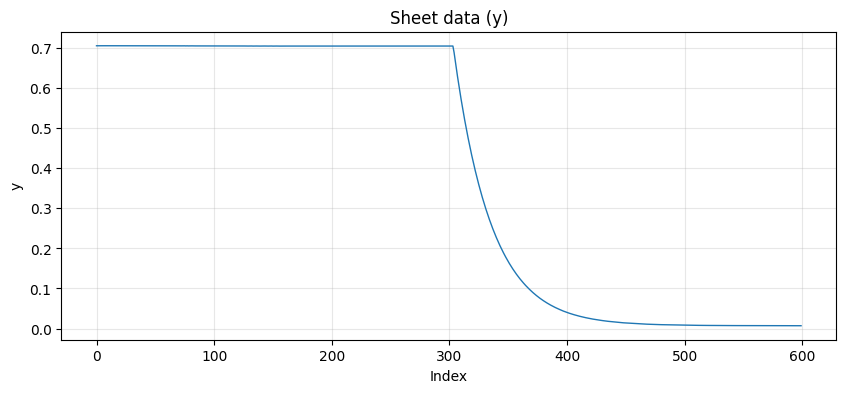

In [3]:
plt.figure(figsize=(10, 4))
plt.plot(sheet.index, sheet["y"], linewidth=1)
plt.xlabel("Sample Index")
plt.ylabel("Voltage RMS")
plt.title("I forgot what this is")
plt.grid(True, alpha=0.3)
plt.show()

2 V_pp at 1kHz changing to 0.02 V_pp after a few seconds.

0.7 ~ 1/sqrt(2) * fundamental @ 1kHz

since the lockin only measures the fundamental, and measures the rms. not 2f, 3f, 4f, etc.


## experiment 3

In [48]:
sheet = pd.read_csv('exp3/exp3_3(T = 1.0E+0 ).xls')

val = sheet["y"][:110].mean() / np.e
tm_idx = np.abs(sheet["y"] - val).argmin()
print(tm_idx)

mu = sheet["y"][:110].mean()
sig = sheet["y"][:110].std()
flip_idx = np.array(np.where(mu - 1.5*sig < sheet["y"][:150])).max()
print(flip_idx)

154
121


Time Constant: 1.03125


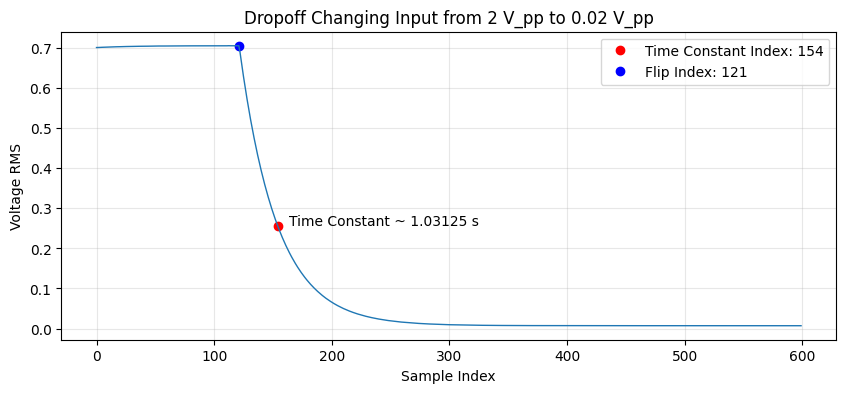

In [89]:

plt.figure(figsize=(10, 4))

plt.plot(tm_idx, sheet["y"][tm_idx], 'ro', label=f"Time Constant Index: {tm_idx}")
plt.plot(flip_idx, sheet["y"][flip_idx], 'bo', label=f"Flip Index: {flip_idx}")

# calculate TC via sample rate
time_constant = (tm_idx - flip_idx) / 32
print(f"Time Constant: {time_constant}")

plt.annotate(f"Time Constant ~ {time_constant:.5f} s", xy=(tm_idx, sheet["y"][tm_idx]), xytext=(tm_idx+10, sheet["y"][tm_idx]))

plt.plot(sheet.index, sheet["y"], linewidth=1)
plt.xlabel("Sample Index")
plt.ylabel("Voltage RMS")
plt.title("Dropoff Changing Input from 2 V_pp to 0.02 V_pp")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

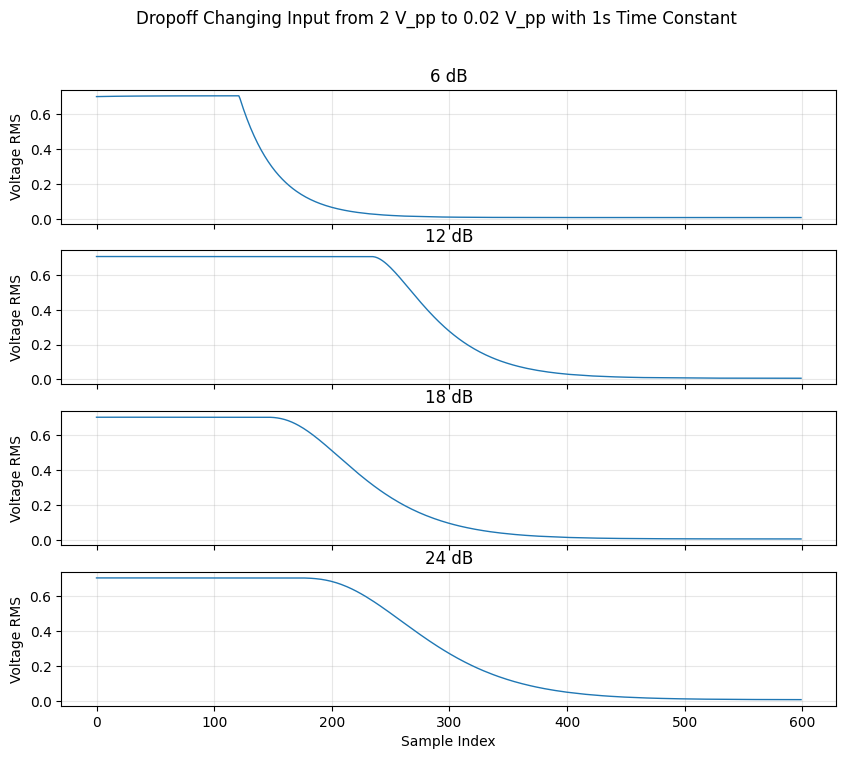

In [56]:
sh1 = pd.read_csv('exp3/exp3_3(T = 1.0E+0 ).xls')
sh2 = pd.read_csv('exp3/exp3_12dB(T = 1.0E+0 ).xls')
sh3 = pd.read_csv('exp3/exp3_18dB(T = 1.0E+0 ).xls')
sh4 = pd.read_csv('exp3/exp3_24dB(T = 1.0E+0 ).xls')

fig, ax = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

fig.suptitle("Dropoff Changing Input from 2 V_pp to 0.02 V_pp with 1s Time Constant")

ax[0].plot(sh1.index, sh1["y"], linewidth=1)
ax[0].set_ylabel("Voltage RMS")
ax[0].set_title("6 dB")
ax[0].grid(True, alpha=0.3)

ax[1].plot(sh2.index, sh2["y"], linewidth=1)
ax[1].set_ylabel("Voltage RMS")
ax[1].set_title("12 dB")
ax[1].grid(True, alpha=0.3)

ax[2].plot(sh3.index, sh3["y"], linewidth=1)
ax[2].set_ylabel("Voltage RMS")
ax[2].set_title("18 dB")
ax[2].grid(True, alpha=0.3)

ax[3].plot(sh4.index, sh4["y"], linewidth=1)
ax[3].set_xlabel("Sample Index")
ax[3].set_ylabel("Voltage RMS")
ax[3].set_title("24 dB")
ax[3].grid(True, alpha=0.3)
plt.show()

3s seconds option

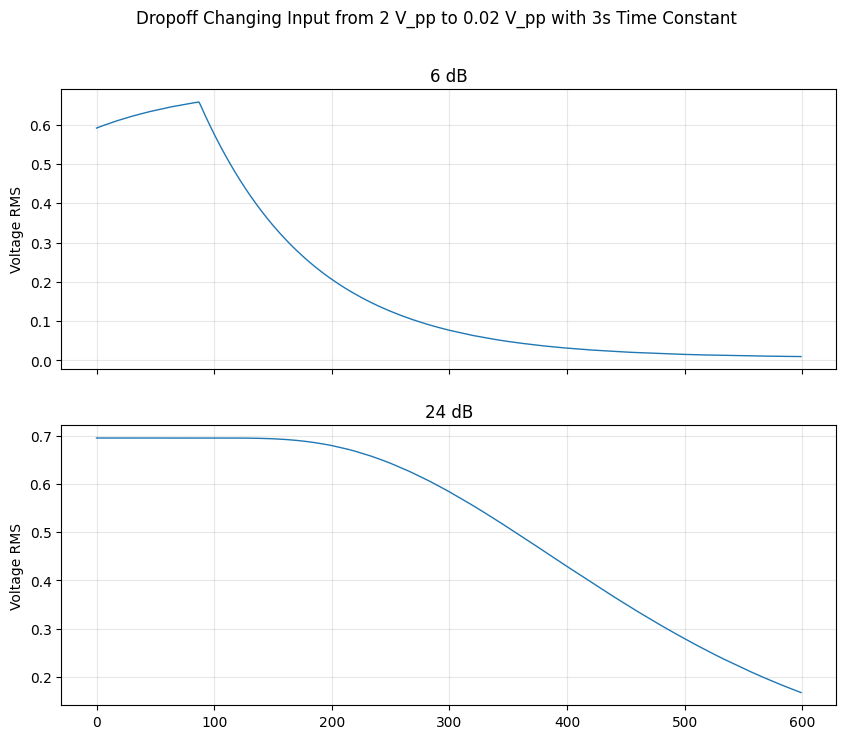

In [55]:
sh1 = pd.read_csv('exp3/exp3_6dB_3s(T = 3.0E+0 ).xls')
sh4 = pd.read_csv('exp3/exp3_24dB_3s(T = 3.0E+0 ).xls')

fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

fig.suptitle("Dropoff Changing Input from 2 V_pp to 0.02 V_pp with 3s Time Constant")

ax[0].plot(sh1.index, sh1["y"], linewidth=1)
ax[0].set_ylabel("Voltage RMS")
ax[0].set_title("6 dB")
ax[0].grid(True, alpha=0.3)

ax[1].plot(sh4.index, sh4["y"], linewidth=1)
ax[1].set_ylabel("Voltage RMS")
ax[1].set_title("24 dB")
ax[1].grid(True, alpha=0.3)

plt.show()

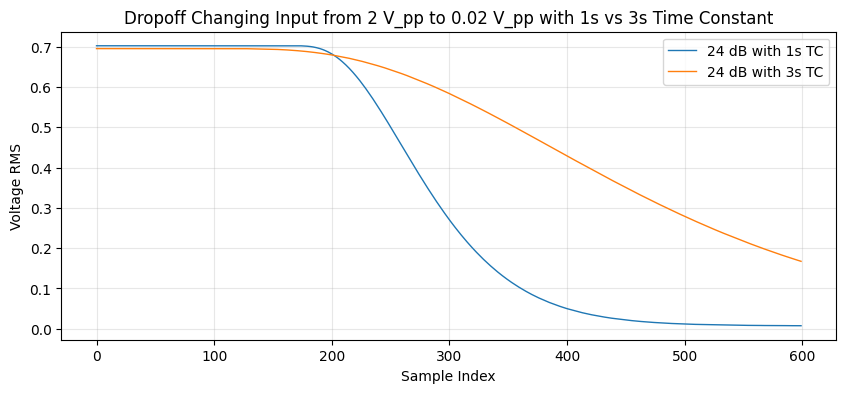

In [57]:
sh1 = pd.read_csv('exp3/exp3_24dB(T = 1.0E+0 ).xls')
sh4 = pd.read_csv('exp3/exp3_24dB_3s(T = 3.0E+0 ).xls')

plt.figure(figsize=(10, 4))
plt.plot(sh1.index, sh1["y"], label="24 dB with 1s TC", linewidth=1)
plt.plot(sh4.index, sh4["y"], label="24 dB with 3s TC", linewidth=1)
plt.xlabel("Sample Index")
plt.ylabel("Voltage RMS")
plt.title("Dropoff Changing Input from 2 V_pp to 0.02 V_pp with 1s vs 3s Time Constant")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## experiment 4

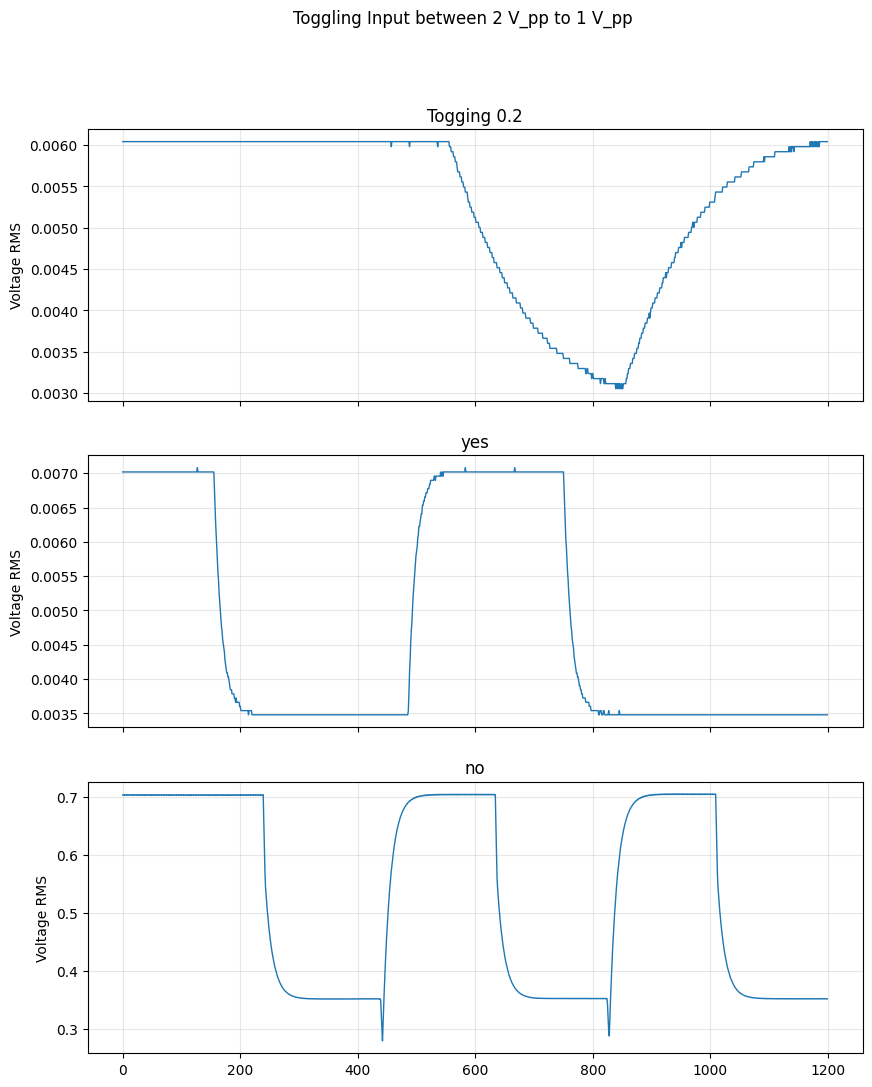

In [63]:

sh1 = pd.read_csv('exp4/exp4(T = 1.0E+0 ).xls')
sh2 = pd.read_csv('exp4/exp4_trial2(T = 100.0E-3 ).xls')
sh3 = pd.read_csv('exp4/exp4_trial3(T = 100.0E-3 ).xls')

fig, ax = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
fig.suptitle("Toggling Input between 2 V_pp to 1 V_pp")

ax[0].plot(sh1.index, sh1["y"], linewidth=1)
ax[0].set_ylabel("Voltage RMS")
ax[0].set_title("Togging 0.2")
ax[0].grid(True, alpha=0.3)

ax[1].plot(sh2.index, sh2["y"], linewidth=1)
ax[1].set_ylabel("Voltage RMS")
ax[1].set_title("yes")
ax[1].grid(True, alpha=0.3)

ax[2].plot(sh3.index, sh3["y"], linewidth=1)
ax[2].set_ylabel("Voltage RMS")
ax[2].set_title("no")
ax[2].grid(True, alpha=0.3)

plt.show()

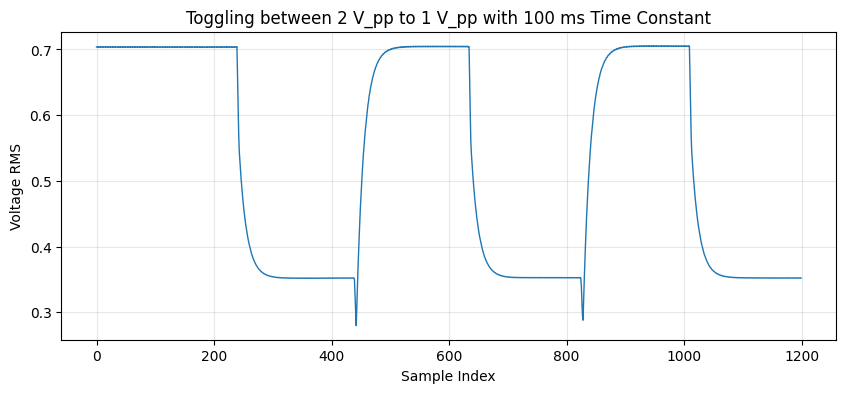

In [66]:

plt.figure(figsize=(10, 4))
plt.plot(sh3.index, sh3["y"], linewidth=1)
plt.xlabel("Sample Index")
plt.ylabel("Voltage RMS")
plt.title("Toggling between 2 V_pp to 1 V_pp with 100 ms Time Constant")
plt.grid(True, alpha=0.3)
plt.show()

### exp 6

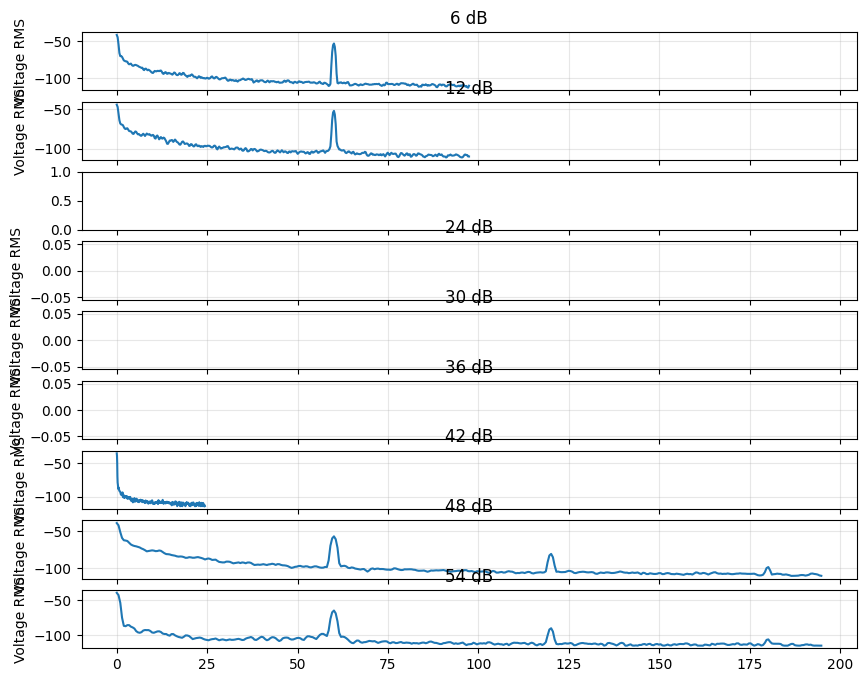

In [69]:
sh1 = pd.read_csv('exp6/exp6_trial2-decent-results', delimiter='\t')
sh2 = pd.read_csv('exp6/exp6_trial1-decent', delimiter='\t')
sh3 = pd.read_csv('exp6/exp6_super_zoomed_out', delimiter='\t')
sh4 = pd.read_csv('exp6/exp6', delimiter='\t')
sh5 = pd.read_csv('exp6/exp6_2', delimiter='\t')
sh6 = pd.read_csv('exp6/exp6_2', delimiter='\t')
sh7 = pd.read_csv('exp6/exp6_24.4HzSpan', delimiter='\t')
sh8 = pd.read_csv('exp6/exp6_195HzSpan', delimiter='\t')
sh9 = pd.read_csv('exp6/exp6_195HzSpan_nothumb', delimiter='\t')

fig, ax = plt.subplots(9, 1, figsize=(10, 8), sharex=True)
ax[0].plot(sh1["x"], sh1["y"], '-')
ax[0].set_ylabel("Voltage RMS")
ax[0].set_title("6 dB")
ax[0].grid(True, alpha=0.3)

ax[1].plot(sh2["x"], sh2["y"], '-')
ax[1].set_ylabel("Voltage RMS")
ax[1].set_title("12 dB")
ax[1].grid(True, alpha=0.3)

ax[3].plot(sh4["x"], sh4["y"], '-')
ax[3].set_ylabel("Voltage RMS")
ax[3].set_title("24 dB")
ax[3].grid(True, alpha=0.3)

ax[4].plot(sh5["x"], sh5["y"], '-')
ax[4].set_ylabel("Voltage RMS")
ax[4].set_title("30 dB")
ax[4].grid(True, alpha=0.3)

ax[5].plot(sh6["x"], sh6["y"], '-')
ax[5].set_ylabel("Voltage RMS")
ax[5].set_title("36 dB")
ax[5].grid(True, alpha=0.3)

ax[6].plot(sh7["x"], sh7["y"], '-')
ax[6].set_ylabel("Voltage RMS")
ax[6].set_title("42 dB")
ax[6].grid(True, alpha=0.3)

ax[7].plot(sh8["x"], sh8["y"], '-')
ax[7].set_ylabel("Voltage RMS")
ax[7].set_title("48 dB")
ax[7].grid(True, alpha=0.3)

ax[8].plot(sh9["x"], sh9["y"], '-')
ax[8].set_ylabel("Voltage RMS")
ax[8].set_title("54 dB")
ax[8].grid(True, alpha=0.3)

plt.show()

the above is from the AC source which operates at 60Hz

##### 1/f noise

alpha = 0.7824


C:\Users\curti\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 7 () missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


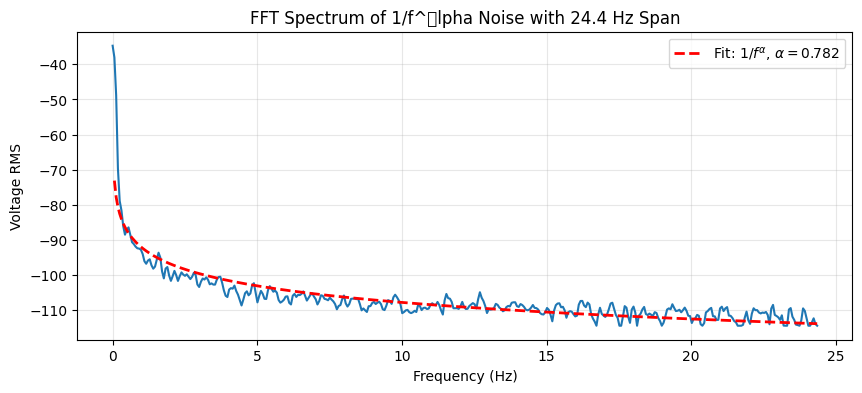

In [96]:

sh7 = pd.read_csv('exp6/exp6_24.4HzSpan', delimiter='\t')

plt.figure(figsize=(10, 4))
plt.plot(sh7["x"], sh7["y"], '-')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Voltage RMS")
plt.title("FFT Spectrum of 1/f^\alpha Noise with 24.4 Hz Span")
plt.grid(True, alpha=0.3)

mask = sh7["x"] > 0  # avoid f=0 for log fit
f = sh7.loc[mask, "x"].to_numpy()
y_db = sh7.loc[mask, "y"].to_numpy()

# Convert dB -> linear amplitude, then fit: A(f) = C * f^(-alpha)
A = 10 ** (y_db / 20.0)
slope, intercept = np.polyfit(np.log(f), np.log(A), 1)
alpha = -slope
C = np.exp(intercept)

# Plot fitted curve back in dB
fit_db = 20 * np.log10(C * f**(-alpha))
plt.plot(f, fit_db, "r--", linewidth=2, label=rf"Fit: $1/f^{{\alpha}}$, $\alpha={alpha:.3f}$")
plt.legend()

print(f"alpha = {alpha:.4f}")
plt.show()


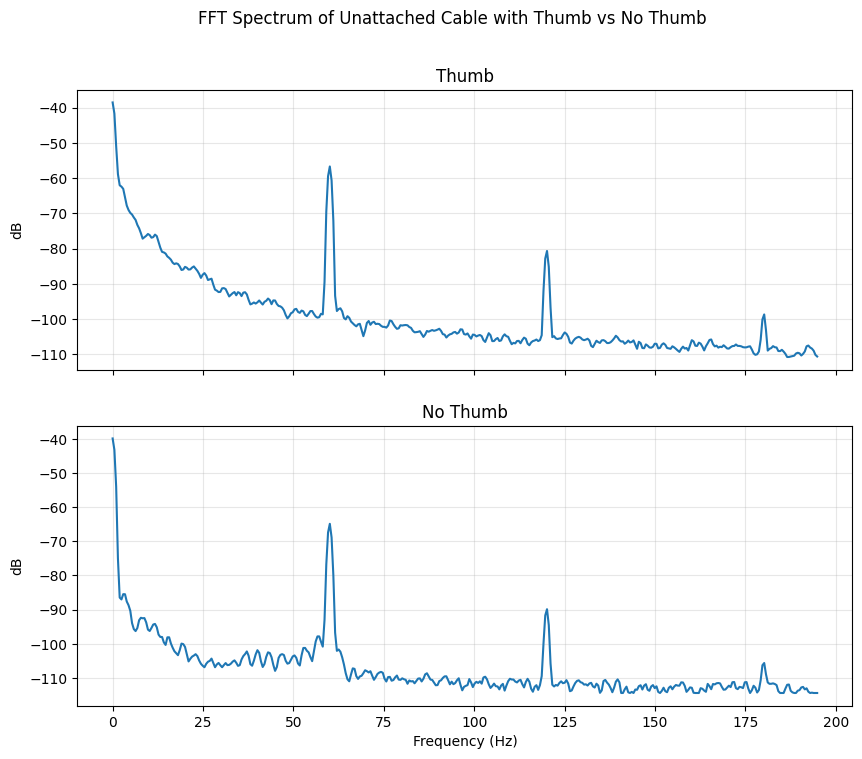

In [91]:
sh8 = pd.read_csv('exp6/exp6_195HzSpan', delimiter='\t')
sh9 = pd.read_csv('exp6/exp6_195HzSpan_nothumb', delimiter='\t')

fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.suptitle("FFT Spectrum of Unattached Cable with Thumb vs No Thumb")

ax[0].plot(sh8["x"], sh8["y"], '-')
ax[0].set_ylabel("dB")
ax[0].set_title("Thumb")
ax[0].grid(True, alpha=0.3)

ax[1].plot(sh9["x"], sh9["y"], '-')
ax[1].set_ylabel("dB")
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_title("No Thumb")
ax[1].grid(True, alpha=0.3)

Measuring with hanging input. Thumb covering the end of the input (like an antenna)

### exp 7

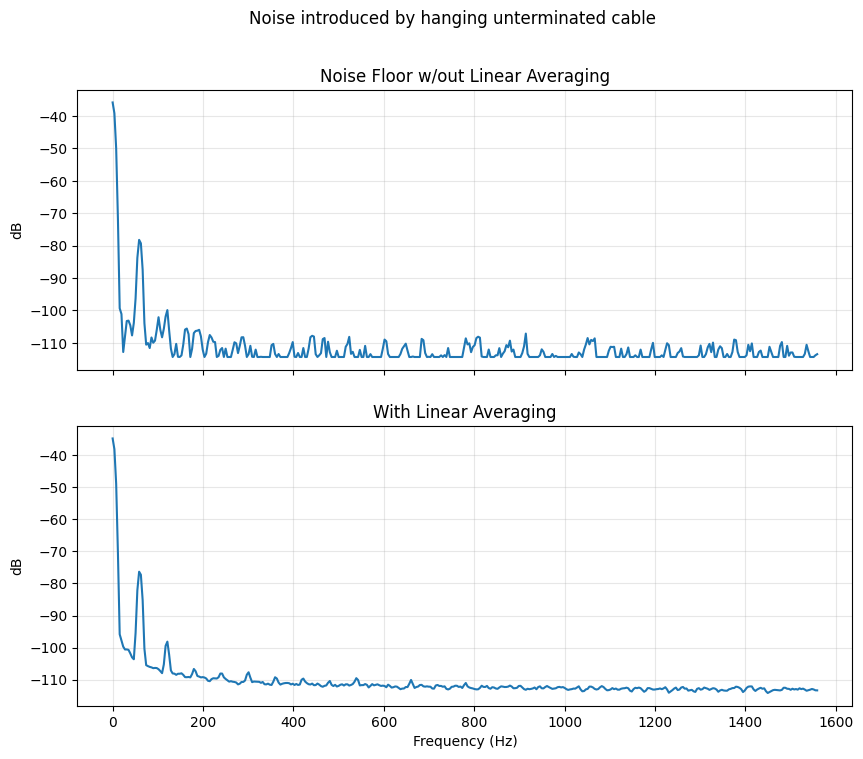

In [120]:
sh1 = pd.read_csv('exp7/exp7_unterminated_q5', delimiter='\t')
sh2 = pd.read_csv('exp7/exp7_unterminated_q5_lin_avg', delimiter='\t')
sh3 = pd.read_csv('exp7/exp7_unterminated_q5_lin_avg_better', delimiter='\t')


fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

fig.suptitle("Noise introduced by hanging unterminated cable")

ax[0].plot(sh1["x"], sh1["y"], '-')
ax[0].set_ylabel("dB")
ax[0].set_title("Noise Floor w/out Linear Averaging")
ax[0].grid(True, alpha=0.3)

ax[1].plot(sh3["x"], sh3["y"], '-')
ax[1].set_ylabel("dB")
ax[1].set_title("With Linear Averaging")
ax[1].grid(True, alpha=0.3)

ax[1].set_xlabel("Frequency (Hz)")

plt.show()


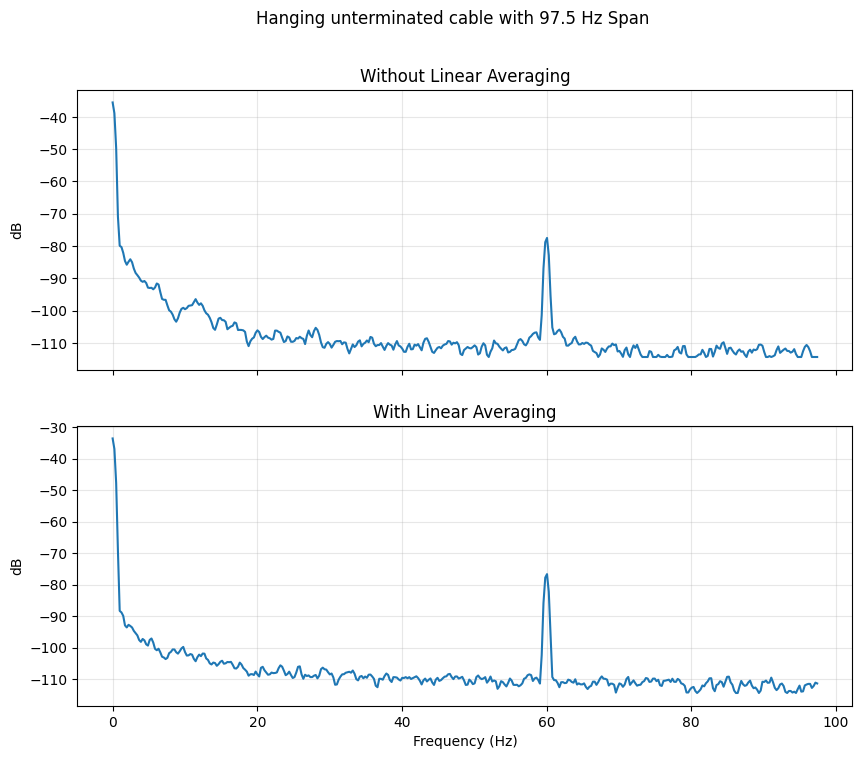

In [135]:
sh1 = pd.read_csv('exp7/exp7_unterminated_q6', delimiter='\t')
sh2 = pd.read_csv('exp7/exp7_unterminated_q6_lin_av', delimiter='\t')


fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.suptitle("Hanging unterminated cable with 97.5 Hz Span")
ax[0].plot(sh1["x"], sh1["y"], '-')
ax[0].set_ylabel("dB")
ax[0].set_title("Without Linear Averaging")
ax[0].grid(True, alpha=0.3)

ax[1].plot(sh2["x"], sh2["y"], '-')
ax[1].set_ylabel("dB")
ax[1].set_title("With Linear Averaging")
ax[1].grid(True, alpha=0.3)
ax[1].set_xlabel("Frequency (Hz)")
plt.show()

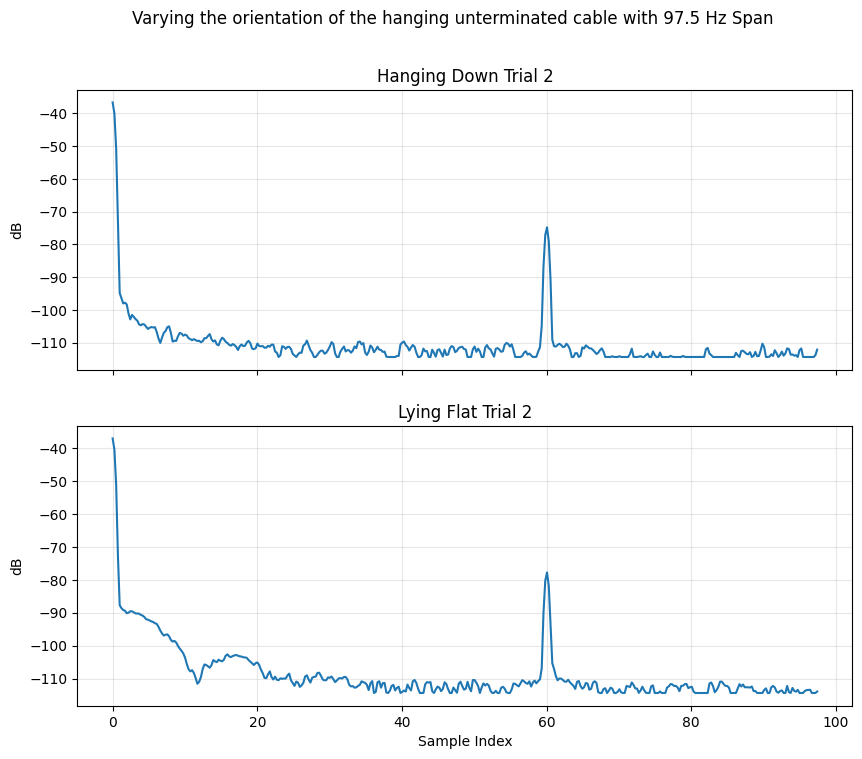

In [134]:
sh1 = pd.read_csv('exp7/exp7_unterminated_q8_hanging_down', delimiter='\t')
sh2 = pd.read_csv('exp7/exp7_unterminated_q8_hanging_down_trial2', delimiter='\t')
sh3 = pd.read_csv('exp7/exp7_unterminated_q8_lying_flat', delimiter='\t')
sh4 = pd.read_csv('exp7/exp7_unterminated_q8_lying_flat_trial_2', delimiter='\t')


fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.suptitle("Varying the orientation of the hanging unterminated cable with 97.5 Hz Span")

# ax[0].plot(sh1["x"], sh1["y"], '-')
# ax[0].set_ylabel("Voltage RMS")
# ax[0].set_title("Hanging Down")
# ax[0].grid(True, alpha=0.3)

ax[0].plot(sh2["x"], sh2["y"], '-')
ax[0].set_ylabel("dB")
ax[0].set_title("Hanging Down Trial 2")
ax[0].grid(True, alpha=0.3)

# ax[2].plot(sh3["x"], sh3["y"], '-')
# ax[2].set_ylabel("Voltage RMS")
# ax[2].set_title("Lying Flat")
# ax[2].grid(True, alpha=0.3)

ax[1].plot(sh4["x"], sh4["y"], '-')
ax[1].set_ylabel("dB")
ax[1].set_title("Lying Flat Trial 2")
ax[1].grid(True, alpha=0.3)

ax[1].set_xlabel("Sample Index")

plt.show()

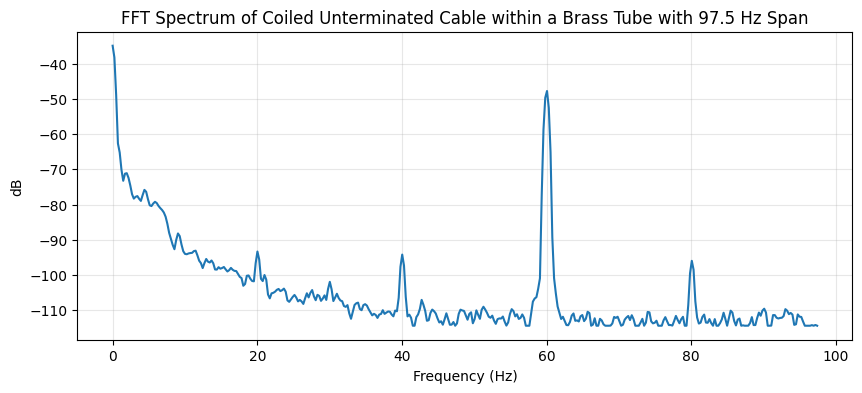

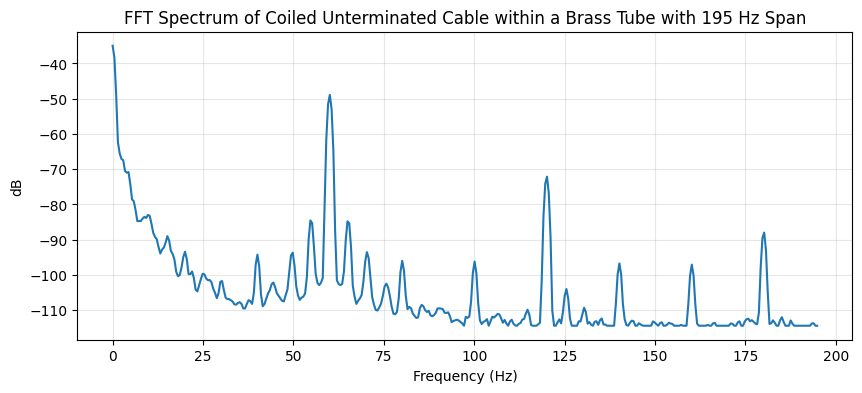

In [133]:
sh1 = pd.read_csv('exp7/exp7_unterminated_q9_coiled_97.5HzSpan', delimiter='\t')
sh2 = pd.read_csv('exp7/exp7_unterminated_q9_coiled_195HzSpan', delimiter='\t')

# fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
# fig.suptitle("FFT Spectrum of Coiled Unterminated Cable within a Brass Tube")

plt.figure(figsize=(10, 4))
plt.plot(sh1["x"], sh1["y"], '-')
plt.ylabel("dB")
plt.title("FFT Spectrum of Coiled Unterminated Cable within a Brass Tube with 97.5 Hz Span")
plt.grid(True, alpha=0.3)
plt.xlabel("Frequency (Hz)")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(sh2["x"], sh2["y"], '-')
plt.ylabel("dB")
plt.title("FFT Spectrum of Coiled Unterminated Cable within a Brass Tube with 195 Hz Span")
plt.grid(True, alpha=0.3)
plt.xlabel("Frequency (Hz)")
plt.show()

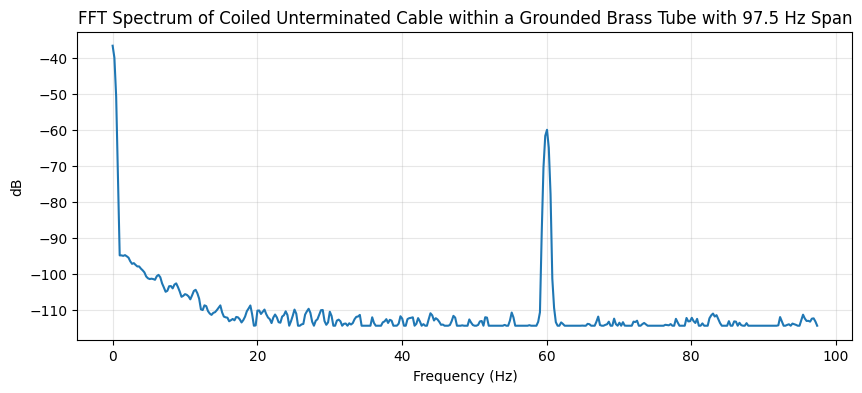

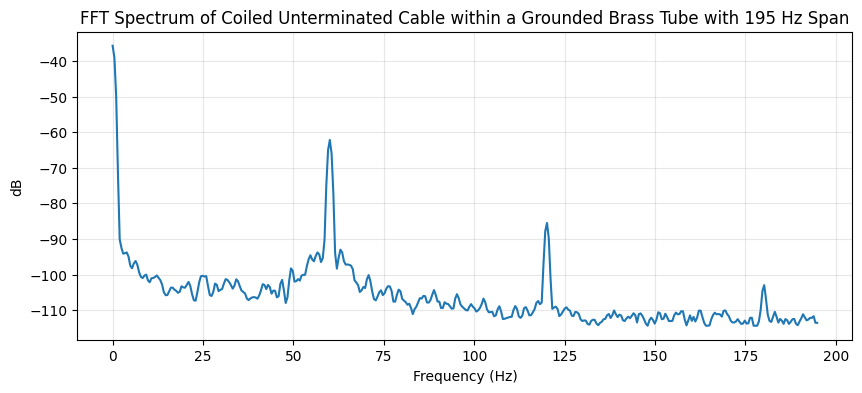

In [137]:

sh1 = pd.read_csv('exp7/exp7_unterminated_q10_coiled_97.5HzSpan_grounded', delimiter='\t')
sh2 = pd.read_csv('exp7/exp7_unterminated_q10_coiled_195HzSpan_grounded', delimiter='\t')

# fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
# fig.suptitle("FFT Spectrum of Coiled Unterminated Cable within a Brass Tube")

plt.figure(figsize=(10, 4))
plt.plot(sh1["x"], sh1["y"], '-')
plt.ylabel("dB")
plt.title("FFT Spectrum of Coiled Unterminated Cable within a Grounded Brass Tube with 97.5 Hz Span")
plt.grid(True, alpha=0.3)
plt.xlabel("Frequency (Hz)")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(sh2["x"], sh2["y"], '-')
plt.ylabel("dB")
plt.title("FFT Spectrum of Coiled Unterminated Cable within a Grounded Brass Tube with 195 Hz Span")
plt.grid(True, alpha=0.3)
plt.xlabel("Frequency (Hz)")
plt.show()

### exp 8

microphonic noise, shaking of the cable

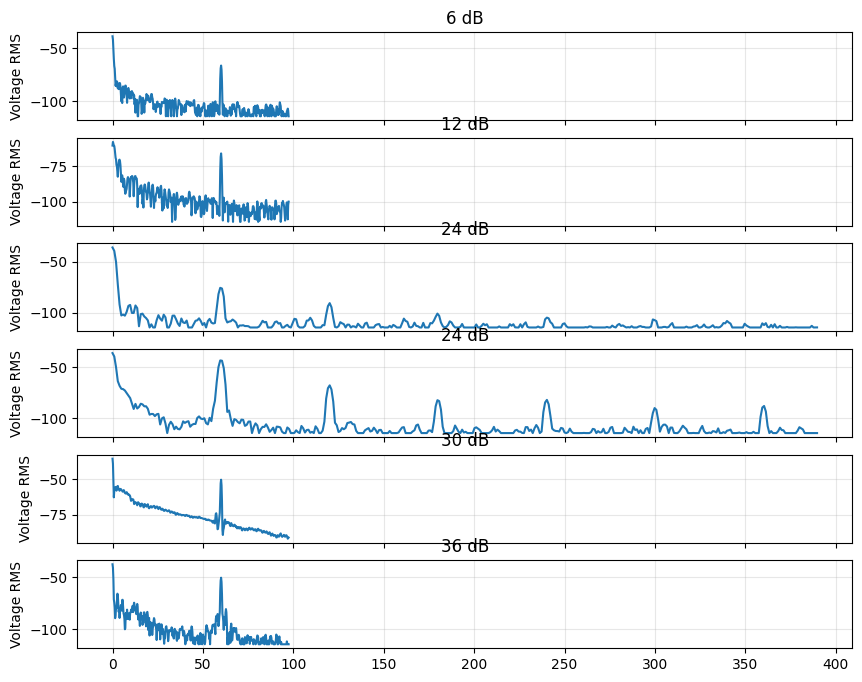

In [76]:
sh1 = pd.read_csv('exp8/exp8_no_lin_av', delimiter='\t')
sh2 = pd.read_csv('exp8/exp8_no_offset', delimiter='\t')
sh3 = pd.read_csv('exp8/exp8_q5_390HzSpan_no_offset', delimiter='\t')
sh4 = pd.read_csv('exp8/exp8_q5_390HzSpan_shaking', delimiter='\t')
sh5 = pd.read_csv('exp8/exp8_shaking_wire_no_lin_av', delimiter='\t')
sh6 = pd.read_csv('exp8/exp8_shaking_wire_no_offset', delimiter='\t')

fig, ax = plt.subplots(6, 1, figsize=(10, 8), sharex=True)
ax[0].plot(sh1["x"], sh1["y"], '-')
ax[0].set_ylabel("Voltage RMS")
ax[0].set_title("6 dB")
ax[0].grid(True, alpha=0.3)

ax[1].plot(sh2["x"], sh2["y"], '-')
ax[1].set_ylabel("Voltage RMS")
ax[1].set_title("12 dB")
ax[1].grid(True, alpha=0.3)

ax[2].plot(sh3["x"], sh3["y"], '-')
ax[2].set_ylabel("Voltage RMS")
ax[2].set_title("24 dB")
ax[2].grid(True, alpha=0.3)

ax[3].plot(sh4["x"], sh4["y"], '-')
ax[3].set_ylabel("Voltage RMS")
ax[3].set_title("24 dB")
ax[3].grid(True, alpha=0.3)

ax[4].plot(sh5["x"], sh5["y"], '-')
ax[4].set_ylabel("Voltage RMS")
ax[4].set_title("30 dB")
ax[4].grid(True, alpha=0.3)

ax[5].plot(sh6["x"], sh6["y"], '-')
ax[5].set_ylabel("Voltage RMS")
ax[5].set_title("36 dB")
ax[5].grid(True, alpha=0.3)

plt.show()

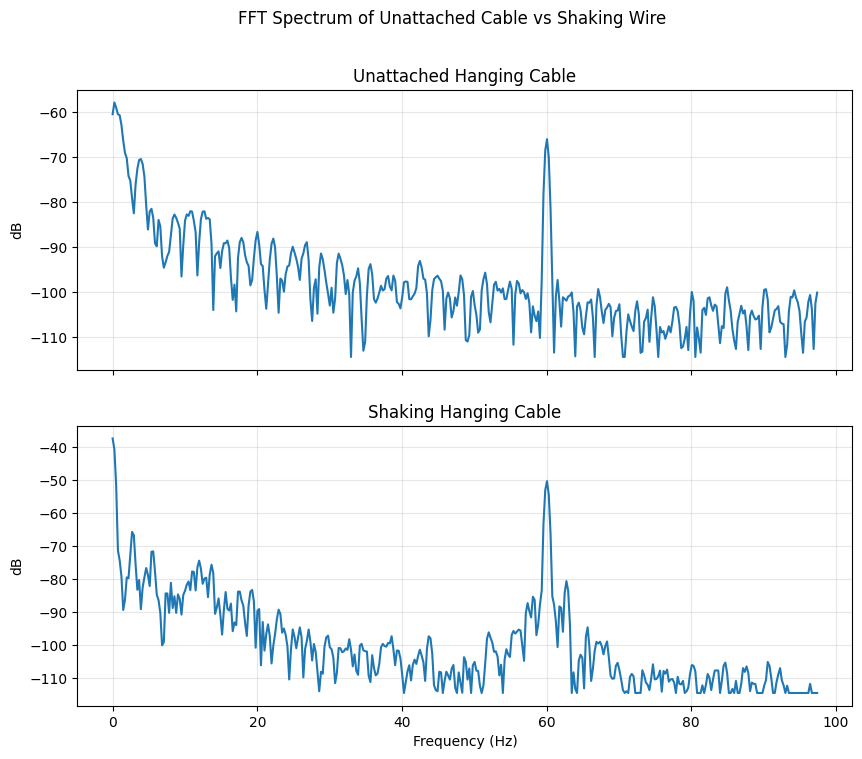

In [93]:
sh2 = pd.read_csv('exp8/exp8_no_offset', delimiter='\t')
sh6 = pd.read_csv('exp8/exp8_shaking_wire_no_offset', delimiter='\t')

fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.suptitle("FFT Spectrum of Unattached Cable vs Shaking Wire")

ax[0].plot(sh2["x"], sh2["y"], '-')
ax[0].set_ylabel("dB")
ax[0].set_title("Unattached Hanging Cable")
ax[0].grid(True, alpha=0.3)

ax[1].plot(sh6["x"], sh6["y"], '-')
ax[1].set_ylabel("dB")
ax[1].set_title("Shaking Hanging Cable")
ax[1].set_xlabel("Frequency (Hz)")
ax[1].grid(True, alpha=0.3)

plt.show()

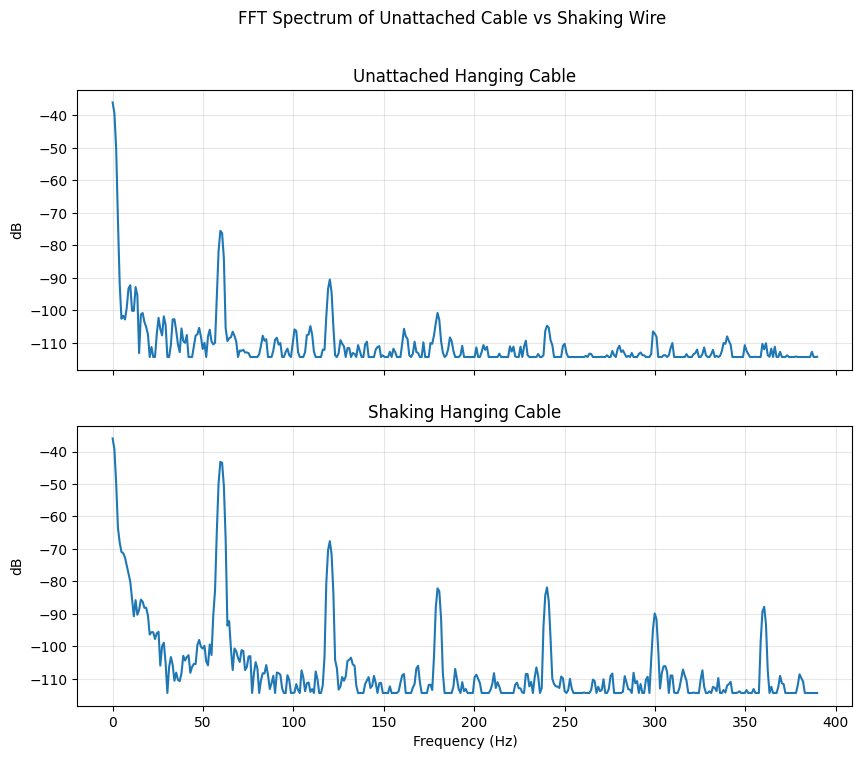

In [94]:
sh3 = pd.read_csv('exp8/exp8_q5_390HzSpan_no_offset', delimiter='\t')
sh4 = pd.read_csv('exp8/exp8_q5_390HzSpan_shaking', delimiter='\t')

fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.suptitle("FFT Spectrum of Unattached Cable vs Shaking Wire")
ax[0].plot(sh3["x"], sh3["y"], '-')
ax[0].set_ylabel("dB")
ax[0].set_title("Unattached Hanging Cable")
ax[0].grid(True, alpha=0.3)

ax[1].plot(sh4["x"], sh4["y"], '-')
ax[1].set_ylabel("dB")
ax[1].set_title("Shaking Hanging Cable")
ax[1].set_xlabel("Frequency (Hz)")
ax[1].grid(True, alpha=0.3)

plt.show()

### exp 9

10k

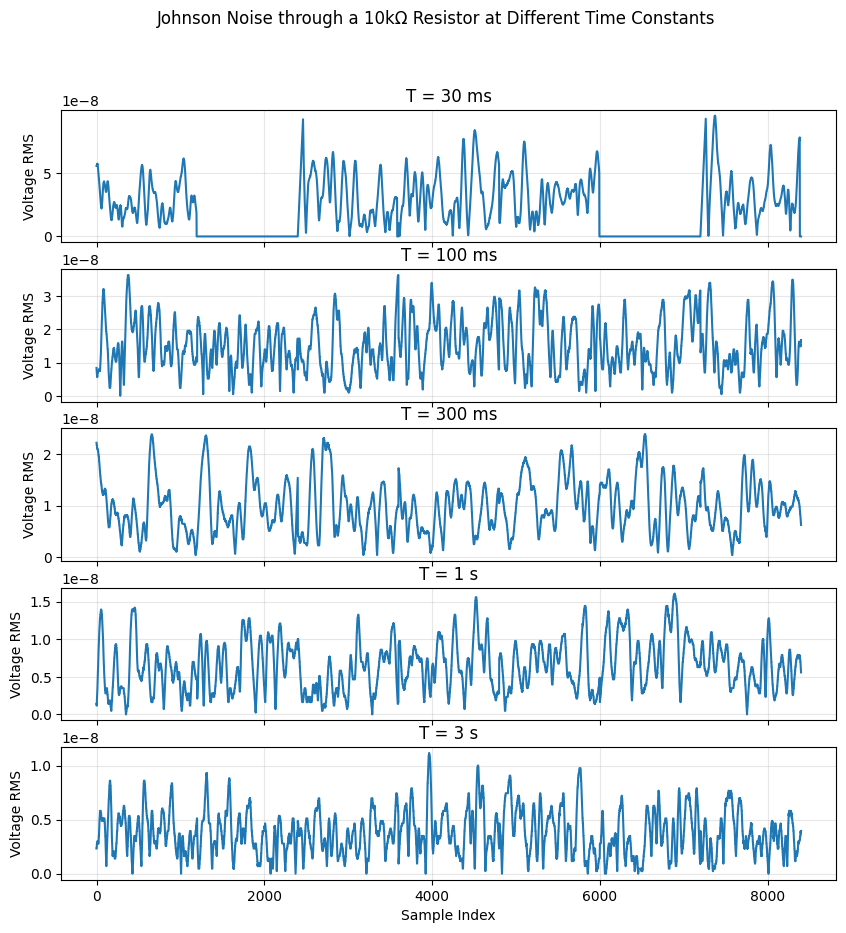

In [110]:
sh1 = pd.read_csv('exp9_10k/trial1(T = 30.0E-3 ).xls')
sh2 = pd.read_csv('exp9_10k/trial2(T = 100.0E-3 ).xls')
sh3 = pd.read_csv('exp9_10k/trial3(T = 300.0E-3 ).xls')
sh4 = pd.read_csv('exp9_10k/trial4(T = 1.0E+0 ).xls')
sh5 = pd.read_csv('exp9_10k/trial5(T = 3.0E+0 ).xls')



fig, ax = plt.subplots(5, 1, figsize=(10, 10), sharex=True)
fig.suptitle("Johnson Noise through a 10kΩ Resistor at Different Time Constants")

ax[0].plot(sh1.index, sh1["y"], '-')
ax[0].set_ylabel("Voltage RMS")
ax[0].set_title("T = 30 ms")


q1 = sh1["y"].quantile(0.25)
q3 = sh1["y"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

sh1 = sh1[(sh1["y"] >= lower) & (sh1["y"] <= upper)].copy()

ax[0].lines[0].set_data(sh1.index, sh1["y"])
ax[0].relim()
ax[0].autoscale_view()
ax[0].grid(True, alpha=0.3)

ax[1].plot(sh2.index, sh2["y"], '-')
ax[1].set_ylabel("Voltage RMS")
ax[1].set_title("T = 100 ms")
ax[1].grid(True, alpha=0.3)

ax[2].plot(sh3.index, sh3["y"], '-')
ax[2].set_ylabel("Voltage RMS")
ax[2].set_title("T = 300 ms")
ax[2].grid(True, alpha=0.3)

ax[3].plot(sh4.index, sh4["y"], '-')
ax[3].set_ylabel("Voltage RMS")
ax[3].set_title("T = 1 s")
ax[3].grid(True, alpha=0.3)

ax[4].plot(sh5.index, sh5["y"], '-')
ax[4].set_ylabel("Voltage RMS")
ax[4].set_title("T = 3 s")
ax[4].grid(True, alpha=0.3)

ax[4].set_xlabel("Sample Index")

plt.show()

100k

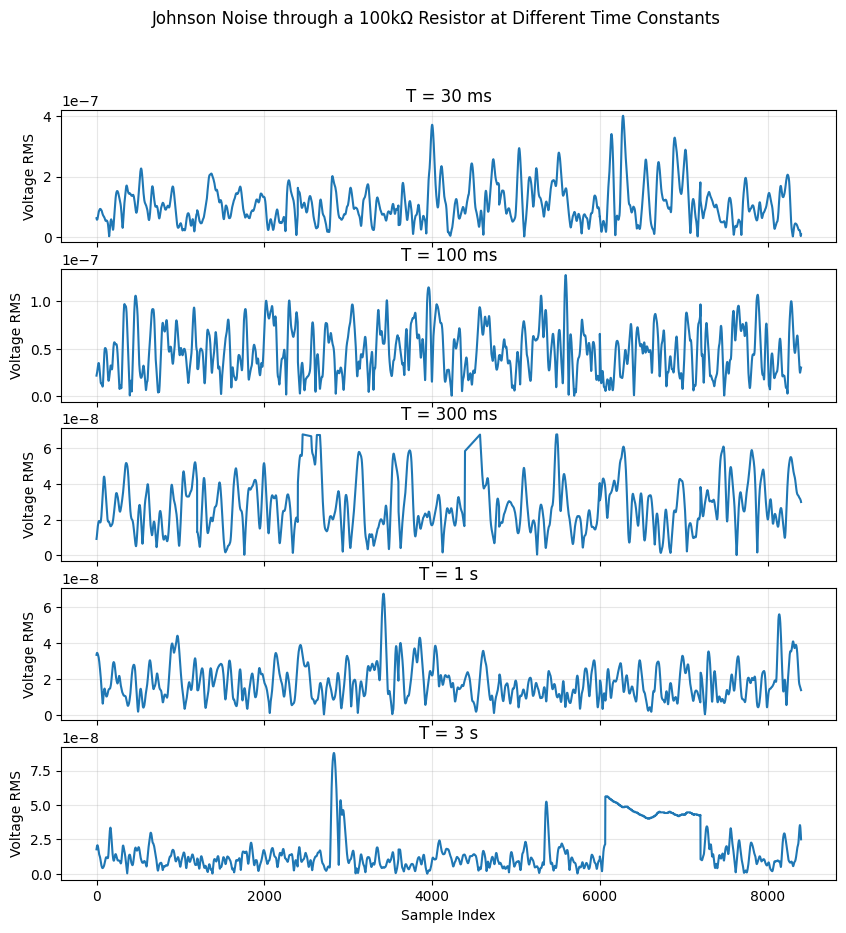

In [107]:
sh1 = pd.read_csv('exp9_100k/exp9_trial1(T = 30.0E-3 ).xls')
sh2 = pd.read_csv('exp9_100k/exp9_trial2(T = 100.0E-3 ).xls')
sh3 = pd.read_csv('exp9_100k/exp9_trial3(T = 300.0E-3 ).xls')
sh4 = pd.read_csv('exp9_100k/exp9_trial4(T = 1.0E+0 ).xls')
sh5 = pd.read_csv('exp9_100k/exp9_trial5(T = 3.0E+0 ).xls')

fig, ax = plt.subplots(5, 1, figsize=(10, 10), sharex=True)
fig.suptitle("Johnson Noise through a 100kΩ Resistor at Different Time Constants")

ax[0].plot(sh1.index, sh1["y"], '-')
ax[0].set_ylabel("Voltage RMS")
ax[0].set_title("T = 30 ms")
ax[0].grid(True, alpha=0.3)

ax[1].plot(sh2.index, sh2["y"], '-')
ax[1].set_ylabel("Voltage RMS")
ax[1].set_title("T = 100 ms")
ax[1].grid(True, alpha=0.3)

q1_sh3 = sh3["y"].quantile(0.25)
q3_sh3 = sh3["y"].quantile(0.75)
iqr_sh3 = q3_sh3 - q1_sh3
lower_sh3 = q1_sh3 - 1.5 * iqr_sh3
upper_sh3 = q3_sh3 + 1.5 * iqr_sh3

sh3 = sh3[(sh3["y"] >= lower_sh3) & (sh3["y"] <= upper_sh3)].copy()

ax[2].plot(sh3.index, sh3["y"], '-')
ax[2].set_ylabel("Voltage RMS")
ax[2].set_title("T = 300 ms")
ax[2].grid(True, alpha=0.3)

ax[3].plot(sh4.index, sh4["y"], '-')
ax[3].set_ylabel("Voltage RMS")
ax[3].set_title("T = 1 s")
ax[3].grid(True, alpha=0.3)

ax[4].plot(sh5.index, sh5["y"], '-')
ax[4].set_ylabel("Voltage RMS")
ax[4].set_title("T = 3 s")
ax[4].grid(True, alpha=0.3)

ax[4].set_xlabel("Sample Index")

plt.show()

### exp 11

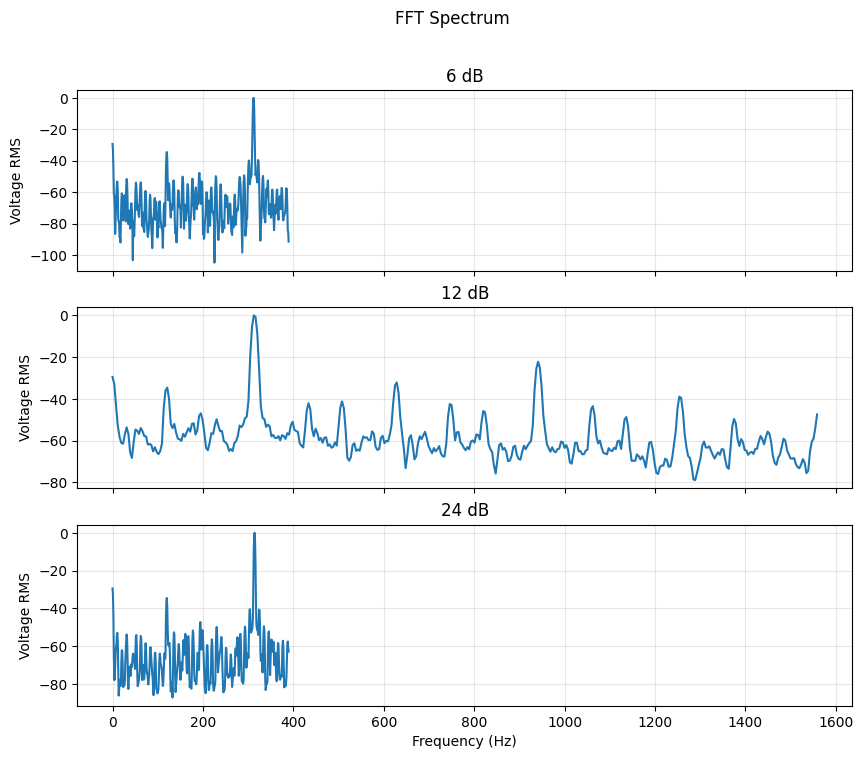

In [84]:
one = pd.read_csv('exp11/exp11_fft', delimiter='\t')
two = pd.read_csv('exp11/exp11_fft_larger_span', delimiter='\t')
three = pd.read_csv('exp11/exp11_fft_li_av', delimiter='\t')


fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig.suptitle("FFT Spectrum")

ax[0].plot(one["x"], one["y"], '-')
ax[0].set_ylabel("Voltage RMS")
ax[0].set_title("6 dB")
ax[0].grid(True, alpha=0.3)

ax[1].plot(two["x"], two["y"], '-')
ax[1].set_ylabel("Voltage RMS")
ax[1].set_title("12 dB")
ax[1].grid(True, alpha=0.3)

ax[2].plot(three["x"], three["y"], '-')
ax[2].set_xlabel("Frequency (Hz)")
ax[2].set_ylabel("Voltage RMS")
ax[2].set_title("24 dB")
ax[2].grid(True, alpha=0.3)

plt.show()


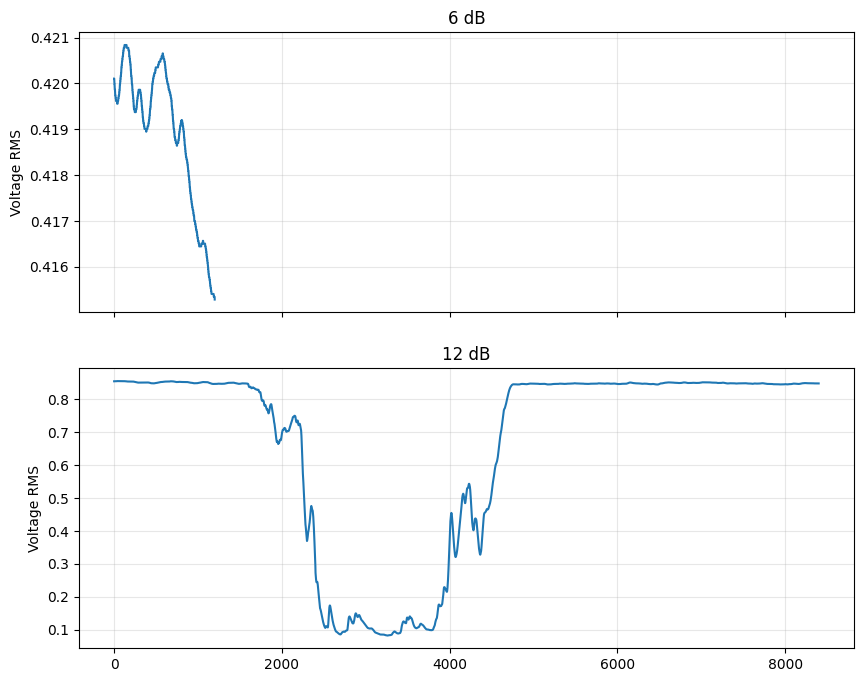

In [73]:
sh1 = pd.read_csv('exp11/exp11_long_run(T = 30.0E+0 ).xls')
sh2 = pd.read_csv('exp11/exp11_long_run2(T = 30.0E+0 ).xls')

fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax[0].plot(sh1.index, sh1["y"], '-')
ax[0].set_ylabel("Voltage RMS")
ax[0].set_title("6 dB")
ax[0].grid(True, alpha=0.3)

ax[1].plot(sh2.index, sh2["y"], '-')
ax[1].set_ylabel("Voltage RMS")
ax[1].set_title("12 dB")
ax[1].grid(True, alpha=0.3)

plt.show()

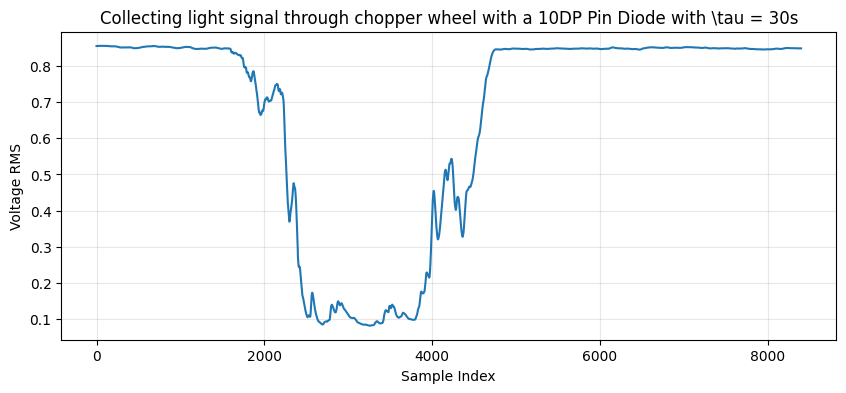

In [99]:
sh2 = pd.read_csv('exp11/exp11_long_run2(T = 30.0E+0 ).xls')

plt.figure(figsize=(10, 4))
plt.plot(sh2.index, sh2["y"])
plt.title("Collecting light signal through chopper wheel with a 10DP Pin Diode with \\tau = 30s")
plt.grid(True, alpha=0.3)
plt.xlabel("Sample Index")
plt.ylabel("Voltage RMS")

plt.show()